In [1]:
# Install and import required libraries
!pip install scikit-learn pandas matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
# Load California Housing Dataset
housing = fetch_california_housing()

# Convert to DataFrame
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['Price'] = housing.target  # target is house price

print("Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (20640, 9)

Column Names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'Price']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
# Check for missing values and basic stats
print("Missing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
df.describe()

Missing Values:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
Price         0
dtype: int64

Descriptive Statistics:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


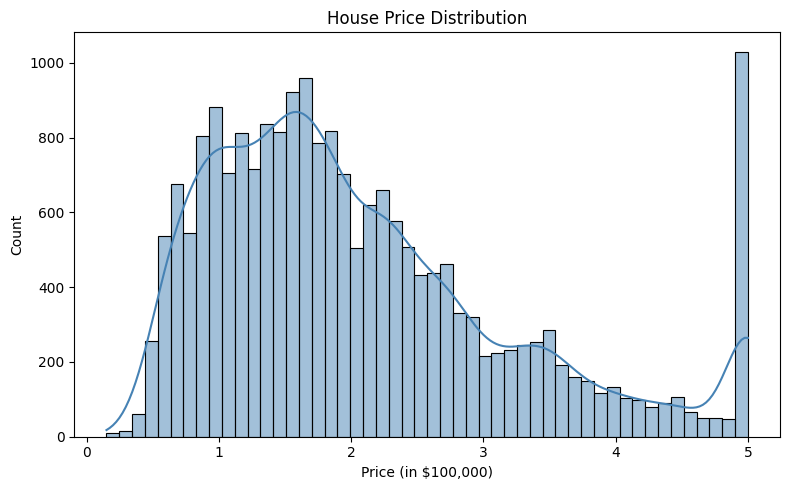

In [4]:
# Distribution of House Prices
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, color='steelblue', kde=True)
plt.title('House Price Distribution')
plt.xlabel('Price (in $100,000)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

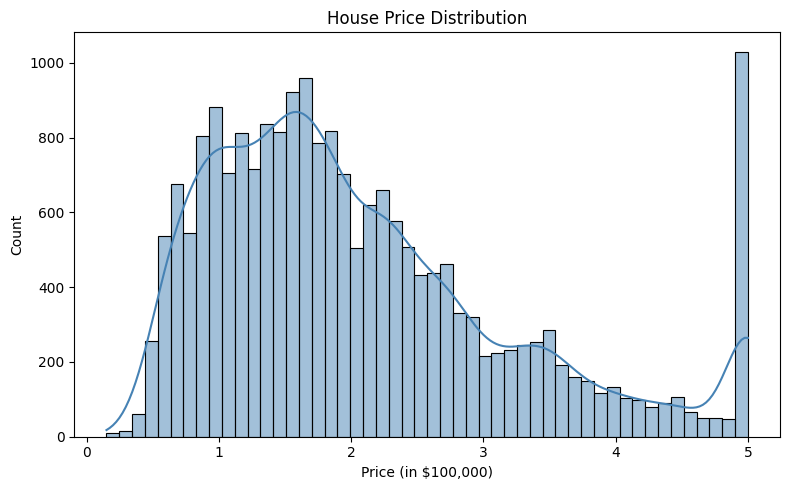

In [5]:
# Distribution of House Prices
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=50, color='steelblue', kde=True)
plt.title('House Price Distribution')
plt.xlabel('Price (in $100,000)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

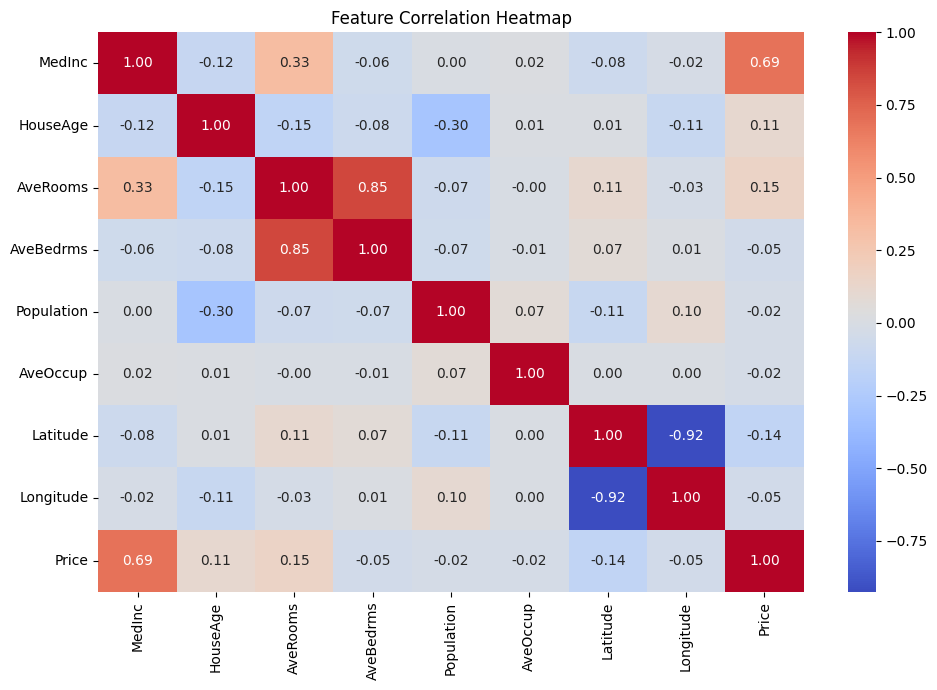

In [6]:
# Correlation between features
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

In [7]:
# Separate features and target
X = df.drop(columns='Price')
y = df['Price']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (16512, 8)
Testing size: (4128, 8)


In [8]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

# Train Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_model.fit(X_train, y_train)
gb_predictions = gb_model.predict(X_test)

print("Both models trained successfully!")

Both models trained successfully!


In [9]:
# Evaluation metrics
def evaluate(name, y_test, predictions):
    mae = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    print(f"{name}:")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print()

evaluate("Linear Regression", y_test, lr_predictions)
evaluate("Gradient Boosting", y_test, gb_predictions)

Linear Regression:
  MAE  : 0.5332
  RMSE : 0.7456

Gradient Boosting:
  MAE  : 0.3717
  RMSE : 0.5422



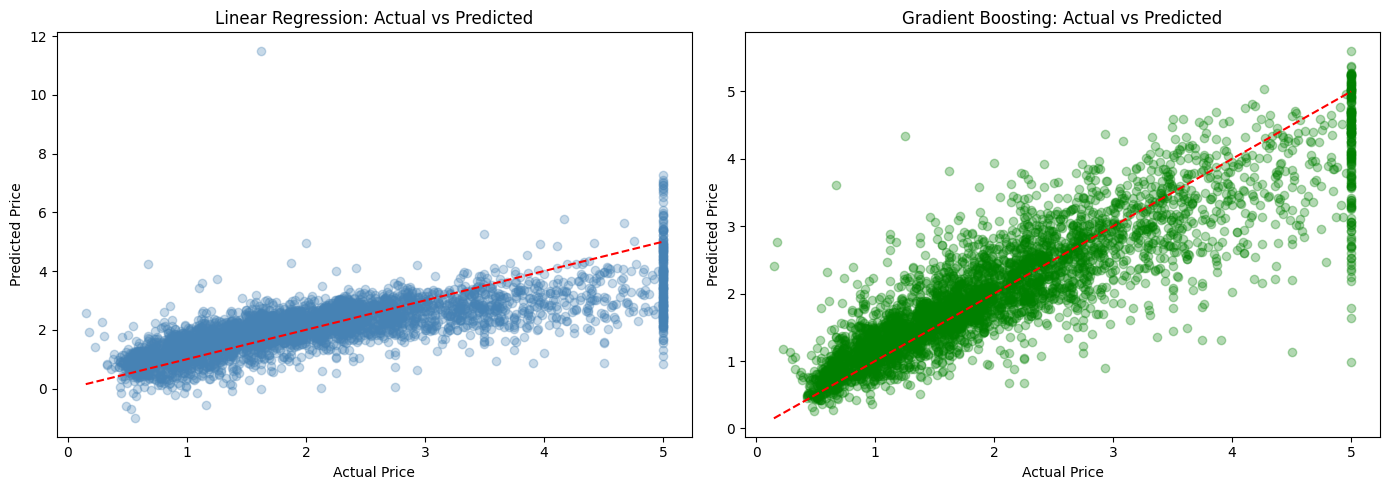

In [10]:
# Compare actual vs predicted prices
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Linear Regression
axes[0].scatter(y_test, lr_predictions, alpha=0.3, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[0].set_title('Linear Regression: Actual vs Predicted')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')

# Gradient Boosting
axes[1].scatter(y_test, gb_predictions, alpha=0.3, color='green')
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--')
axes[1].set_title('Gradient Boosting: Actual vs Predicted')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')

plt.tight_layout()
plt.show()

## Key Findings

- Dataset has 20,640 rows and 8 features
- No missing values found
- MedInc (median income) has strongest correlation with house price
- Gradient Boosting performs significantly better than Linear Regression
- Linear Regression struggles with non-linear patterns in data
- RMSE tells us average prediction error in $100,000 ***units***